### Import Necessary Libraries

In [1]:
# Import all the necessary packages
import warnings
import pandas as pd
import numpy as np
import string
import re
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from IPython.display import Image
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc, confusion_matrix

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

from gensim import matutils, models
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
import warnings
import re

# 針對特定的 datetime 警告訊息進行模糊匹配過濾
warnings.filterwarnings("ignore", message=r".*datetime\.datetime\.utcnow.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

### Data preprocessing

##### Load Data

In [2]:
raw_data = pd.read_csv('/kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv',encoding='ISO-8859-1', header=None).sample(n=100000)

In [3]:
raw_data = raw_data.reset_index(drop=True)

In [4]:
raw_data.head()

,0,1,2,3,4,5
0,4,2014210305,Wed Jun 03 00:47:50 PDT 2009,NO_QUERY,Katie_Saffarii,Watching Buffy at 3:45 am makes me happy... es...
1,0,2060073751,Sat Jun 06 18:12:22 PDT 2009,NO_QUERY,ItzNita,At newark night on main street...bout to go ho...
2,0,1990772647,Mon Jun 01 05:42:28 PDT 2009,NO_QUERY,sparkfly77,"My vacation is over, time to get back to work"
3,0,1970481689,Sat May 30 04:02:32 PDT 2009,NO_QUERY,CrushStyle04,watching Oblongs.....can't sleep
4,4,1881178339,Fri May 22 03:51:38 PDT 2009,NO_QUERY,marge0256,says she can't work anymore. Excited to see a ...


In [5]:
train, test = train_test_split(
    raw_data,
    test_size=0.2,    # 20% of data for testing
    random_state=42,  # for reproducible splits
    shuffle=True      # ensures random distribution
)

In [6]:
train.head()

,0,1,2,3,4,5
75220,0,2056636369,Sat Jun 06 11:30:42 PDT 2009,NO_QUERY,Vernonjm,Oh man! Wi-fi Modem is on the fritz again.Whi...
48955,4,1957458230,Fri May 29 00:33:52 PDT 2009,NO_QUERY,savagestar,"@dividedsequence aww hahaha I'm good, got the ..."
44966,4,1978653458,Sun May 31 00:01:53 PDT 2009,NO_QUERY,Mia_R,@Jaaycooxo curling your hair like selena gomez...
13568,0,2192214293,Tue Jun 16 06:41:38 PDT 2009,NO_QUERY,cebecebe,confusedddd :'( huaaa stresss
92727,4,1997217432,Mon Jun 01 16:27:44 PDT 2009,NO_QUERY,xSugarHIGH,@missladykjones whatever trick. you dont miss ...


In [7]:
test.head()

,0,1,2,3,4,5
75721,0,1751667453,Sat May 09 19:59:27 PDT 2009,NO_QUERY,ishhMee,Stressing over homework *Trying to get throu...
80184,4,1997293387,Mon Jun 01 16:35:45 PDT 2009,NO_QUERY,cm2,"@lesley_v: heh, yeah Sia does some very unusua..."
19864,0,2206599331,Wed Jun 17 06:47:11 PDT 2009,NO_QUERY,OmerK,won't be able to attend the @londonhackspace m...
76699,4,2070172693,Sun Jun 07 17:13:17 PDT 2009,NO_QUERY,jheng87,grad pictures are done &amp; look awesome! thx...
92991,4,1795653263,Thu May 14 08:08:36 PDT 2009,NO_QUERY,caitymay,i love the day after deadline - it's indecentl...


In [8]:
train.to_csv('train.csv',header = None,index=False)
test.to_csv('test.csv',header= None,index=False)

In [9]:
#read the training set and test set
train = pd.read_csv('train.csv',header=None)
test= pd.read_csv('test.csv',header=None)

In [10]:
train.head()

,0,1,2,3,4,5
0,0,2056636369,Sat Jun 06 11:30:42 PDT 2009,NO_QUERY,Vernonjm,Oh man! Wi-fi Modem is on the fritz again.Whi...
1,4,1957458230,Fri May 29 00:33:52 PDT 2009,NO_QUERY,savagestar,"@dividedsequence aww hahaha I'm good, got the ..."
2,4,1978653458,Sun May 31 00:01:53 PDT 2009,NO_QUERY,Mia_R,@Jaaycooxo curling your hair like selena gomez...
3,0,2192214293,Tue Jun 16 06:41:38 PDT 2009,NO_QUERY,cebecebe,confusedddd :'( huaaa stresss
4,4,1997217432,Mon Jun 01 16:27:44 PDT 2009,NO_QUERY,xSugarHIGH,@missladykjones whatever trick. you dont miss ...


In [11]:
test.head()

,0,1,2,3,4,5
0,0,1751667453,Sat May 09 19:59:27 PDT 2009,NO_QUERY,ishhMee,Stressing over homework *Trying to get throu...
1,4,1997293387,Mon Jun 01 16:35:45 PDT 2009,NO_QUERY,cm2,"@lesley_v: heh, yeah Sia does some very unusua..."
2,0,2206599331,Wed Jun 17 06:47:11 PDT 2009,NO_QUERY,OmerK,won't be able to attend the @londonhackspace m...
3,4,2070172693,Sun Jun 07 17:13:17 PDT 2009,NO_QUERY,jheng87,grad pictures are done &amp; look awesome! thx...
4,4,1795653263,Thu May 14 08:08:36 PDT 2009,NO_QUERY,caitymay,i love the day after deadline - it's indecentl...


In [12]:
#Set the column name
train.columns = ['target', 'ids', 'data', 'flag','user','text']
test.columns = ['target', 'ids', 'data', 'flag','user','text']

In [13]:
#training set have 1280023 row and 6 column.
train.shape

(80000, 6)

In [14]:
#test set have 319977 row and 6 column.
test.shape

(20000, 6)

##### Data Preprocessing Functions

In [15]:
#Here is some function for data preprocessing
#remove URLs,punctuations,numbers,nonsensical
#convert emoticons
#remove stop word,frequency word and rare word
#Use PorterStemmer() for Stemming
#Use WordNetLemmatizer() for lemmatizations
#If you don't want to waste the time to run the code, you can just simply read the train_clean.pkl and test_clean.pkl file.
#Read the converted training set and test set
#train_clean= pd.read_pickle('train_clean.pkl')
#test_clean= pd.read_pickle('test_clean.pkl')

def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

def remove_numbers(text):
    return re.sub(r'\d+', '', text) 

def remove_nonsensical(text):
    return text.replace('\n', ' ').replace('\r', ' ')

#Dictionary for converting emoticons
EMOTICONS = {
    r":‑\)": "Happy face or smiley",
    r":\)": "Happy face or smiley",
    r":-\]": "Happy face or smiley",
    r":\]": "Happy face or smiley",
    r":-3": "Happy face smiley",
    r":3": "Happy face smiley",
    r":->": "Happy face smiley",
    r":>": "Happy face smiley",
    r"8-\)": "Happy face smiley",
    r":o\)": "Happy face smiley",
    r":-\}": "Happy face smiley",
    r":\}": "Happy face smiley",
    r":-\)": "Happy face smiley",
    r":c\)": "Happy face smiley",
    r":\^\)": "Happy face smiley",
    r"=\]": "Happy face smiley",
    r"=\)": "Happy face smiley",
    r":‑D": "Laughing, big grin or laugh with glasses",
    r":D": "Laughing, big grin or laugh with glasses",
    r"8‑D": "Laughing, big grin or laugh with glasses",
    r"8D": "Laughing, big grin or laugh with glasses",
    r"X‑D": "Laughing, big grin or laugh with glasses",
    r"XD": "Laughing, big grin or laugh with glasses",
    r"=D": "Laughing, big grin or laugh with glasses",
    r"=3": "Laughing, big grin or laugh with glasses",
    r"B\^D": "Laughing, big grin or laugh with glasses",
    r":-\)\)": "Very happy",
    r":‑\(": "Frown, sad, andry or pouting",
    r":-\(": "Frown, sad, andry or pouting",
    r":\(": "Frown, sad, andry or pouting",
    r":‑c": "Frown, sad, andry or pouting",
    r":c": "Frown, sad, andry or pouting",
    r":‑<": "Frown, sad, andry or pouting",
    r":<": "Frown, sad, andry or pouting",
    r":‑\[": "Frown, sad, andry or pouting",
    r":\[": "Frown, sad, andry or pouting",
    r":-\|\|": "Frown, sad, andry or pouting",
    r">:\[": "Frown, sad, andry or pouting",
    r":\{": "Frown, sad, andry or pouting",
    r":@": "Frown, sad, andry or pouting",
    r">:\(": "Frown, sad, andry or pouting",
    r":'‑\(": "Crying",
    r":'\(": "Crying",
    r":'‑\)": "Tears of happiness",
    r":'\)": "Tears of happiness",
    r"D‑':": "Horror",
    r"D:<": "Disgust",
    r"D:": "Sadness",
    r"D8": "Great dismay",
    r"D;": "Great dismay",
    r"D=": "Great dismay",
    r"DX": "Great dismay",
    r":‑O": "Surprise",
    r":O": "Surprise",
    r":‑o": "Surprise",
    r":o": "Surprise",
    r":-0": "Shock",
    r"8‑0": "Yawn",
    r">:O": "Yawn",
    r":-\*": "Kiss",
    r":\*": "Kiss",
    r":X": "Kiss",
    r";‑\)": "Wink or smirk",
    r";\)": "Wink or smirk",
    r"\*-\)": "Wink or smirk",
    r"\*\)": "Wink or smirk",
    r";‑\]": "Wink or smirk",
    r";\]": "Wink or smirk",
    r";\^\)": "Wink or smirk",
    r":‑,": "Wink or smirk",
    r";D": "Wink or smirk",
    r":‑P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"X‑P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"XP": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":‑Þ": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":Þ": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":b": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"d:": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"=p": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r">:P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":‑/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":-[.]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r">:[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r">:/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":L": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=L": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":S": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":‑\|": "Straight face",
    r":\|": "Straight face",
    r":$": "Embarrassed or blushing",
    r":‑x": "Sealed lips or wearing braces or tongue-tied",
    r":x": "Sealed lips or wearing braces or tongue-tied",
    r":‑#": "Sealed lips or wearing braces or tongue-tied",
    r":#": "Sealed lips or wearing braces or tongue-tied",
    r":‑&": "Sealed lips or wearing braces or tongue-tied",
    r":&": "Sealed lips or wearing braces or tongue-tied",
    r"O:‑\)": "Angel, saint or innocent",
    r"O:\)": "Angel, saint or innocent",
    r"0:‑3": "Angel, saint or innocent",
    r"0:3": "Angel, saint or innocent",
    r"0:‑\)": "Angel, saint or innocent",
    r"0:\)": "Angel, saint or innocent",
    r":‑b": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"0;\^\)": "Angel, saint or innocent",
    r">:‑\)": "Evil or devilish",
    r">:\)": "Evil or devilish",
    r"\}:‑\)": "Evil or devilish",
    r"\}:\)": "Evil or devilish",
    r"3:‑\)": "Evil or devilish",
    r"3:\)": "Evil or devilish",
    r">;\)": "Evil or devilish",
    r"\|;‑\)": "Cool",
    r"\|‑O": "Bored",
    r":‑J": "Tongue-in-cheek",
    r"#‑\)": "Party all night",
    r"%‑\)": "Drunk or confused",
    r"%\)": "Drunk or confused",
    r":-###..": "Being sick",
    r":###..": "Being sick",
    r"<:‑\|": "Dump",
    r"\(>_<\)": "Troubled",
    r"\(>_<\)>": "Troubled",
    r"\(';'\)": "Baby",
    r"\(\^\^>``": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(\^_\^;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(-_-;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(~_~;\) \(・\.・;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(-_-\)zzz": "Sleeping",
    r"\(\^_-\)": "Wink",
    r"\(\(\+_\+\)\)": "Confused",
    r"\(\+o\+\)": "Confused",
    r"\(o\|o\)": "Ultraman",
    r"\^_\^": "Joyful",
    r"\(\^_\^\)/": "Joyful",
    r"\(\^O\^\)／": "Joyful",
    r"\(\^o\^\)／": "Joyful",
    r"\(__\)": "Kowtow as a sign of respect, or dogeza for apology",
    r"_\(\._\.\)_": "Kowtow as a sign of respect, or dogeza for apology",
    r"<\(_ _\)>": "Kowtow as a sign of respect, or dogeza for apology",
    r"<m\(__\)m>": "Kowtow as a sign of respect, or dogeza for apology",
    r"m\(__\)m": "Kowtow as a sign of respect, or dogeza for apology",
    r"m\(_ _\)m": "Kowtow as a sign of respect, or dogeza for apology",
    r"\('_'\)": "Sad or Crying",
    r"\(/_;\)": "Sad or Crying",
    r"\(T_T\) \(;_;\)": "Sad or Crying",
    r"\(;_;": "Sad of Crying",
    r"\(;_:\)": "Sad or Crying",
    r"\(;O;\)": "Sad or Crying",
    r"\(:_;\)": "Sad or Crying",
    r"\(ToT\)": "Sad or Crying",
    r";_;": "Sad or Crying",
    r";-;": "Sad or Crying",
    r";n;": "Sad or Crying",
    r";;": "Sad or Crying",
    r"Q\.Q": "Sad or Crying",
    r"T\.T": "Sad or Crying",
    r"QQ": "Sad or Crying",
    r"Q_Q": "Sad or Crying",
    r"\(-\.-\)": "Shame",
    r"\(-_-\)": "Shame",
    r"\(一一\)": "Shame",
    r"\(；一_一\)": "Shame",
    r"\(=_=\)": "Tired",
    r"\(=\^\·\^=\)": "cat",
    r"\(=\^\·\·\^=\)": "cat",
    r"=_\^=": "cat",
    r"\(\.\.\)": "Looking down",
    r"\(\._\.\)": "Looking down",
    r"\^m\^": "Giggling with hand covering mouth",
    r"\(\・\・?": "Confusion",
    r"\(?_?\)": "Confusion",
    r">\^_\^<": "Normal Laugh",
    r"<\^!\^>": "Normal Laugh",
    r"\^/\^": "Normal Laugh",
    r"\（\*\^_\^\*）": "Normal Laugh",
    r"\(\^<\^\) \(\^\.\^\)": "Normal Laugh",
    r"\(^\^\)": "Normal Laugh",
    r"\(\^\.\^\)": "Normal Laugh",
    r"\(\^_\^\.\)": "Normal Laugh",
    r"\(\^_\^\)": "Normal Laugh",
    r"\(\^\^\)": "Normal Laugh",
    r"\(\^J\^\)": "Normal Laugh",
    r"\(\*\^\.\^\*\)": "Normal Laugh",
    r"\(\^—\^\）": "Normal Laugh",
    r"\(#\^\.\^#\)": "Normal Laugh",
    r"\（\^—\^\）": "Waving",
    r"\(;_;\)/~~~": "Waving",
    r"\(\^\.\^\)/~~~": "Waving",
    r"\(-_-\)/~~~ \($\·\·\)/~~~": "Waving",
    r"\(T_T\)/~~~": "Waving",
    r"\(ToT\)/~~~": "Waving",
    r"\(\*\^0\^\*\)": "Excited",
    r"\(\*_\*\)": "Amazed",
    r"\(\*_\*;": "Amazed",
    r"\(\+_\+\) \(@_@\)": "Amazed",
    r"\(\*\^\^\)v": "Laughing,Cheerful",
    r"\(\^_\^\)v": "Laughing,Cheerful",
    r"\(\(d[-_-]b\)\)": "Headphones,Listening to music",
    r'\(-"-\)': "Worried",
    r"\(ーー;\)": "Worried",
    r"\(\^0_0\^\)": "Eyeglasses",
    r"\(\＾ｖ\＾\)": "Happy",
    r"\(\＾ｕ\＾\)": "Happy",
    r"\(\^\)o\(\^\)": "Happy",
    r"\(\^O\^\)": "Happy",
    r"\(\^o\^\)": "Happy",
    r"\)\^o\^\(": "Happy",
    r":O o_O": "Surprised",
    r"o_0": "Surprised",
    r"o\.O": "Surprised",
    r"\(o\.o\)": "Surprised",
    r"oO": "Surprised",
    r"\(\*￣m￣\)": "Dissatisfied",
    r"\(‘A`\)": "Snubbed or Deflated"}

In [16]:
def convert_emoticons(text):
    for emot in EMOTICONS:
        text = re.sub(u'('+emot+')', "_".join(EMOTICONS[emot].replace(",","").split()), text)
    return text

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

def remove_freqwords(text):
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

def remove_rarewords(text):
    return " ".join([word for word in str(text).split() if word not in RAREWORDS])


def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

def lemmatize_words(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

##### Preprocess the Training and Test Sets

In [17]:
# Convert the traing set
train["text"] = train["text"].str.lower()
train["text"] = train["text"].apply(lambda text: remove_urls(text))
PUNCT_TO_REMOVE = string.punctuation
train["text"] = train["text"].apply(lambda text: remove_punctuation(text))
train["text"] = train["text"].apply(lambda text: remove_numbers(text))
train["text"] = train["text"].apply(lambda text: remove_nonsensical(text))
train["text"] = train["text"].apply(lambda text: convert_emoticons(text))
STOPWORDS = set(stopwords.words('english'))
train["text"] = train["text"].apply(lambda text: remove_stopwords(text))
cnt = Counter()
for text in train["text"].values:
    for word in text.split():
        cnt[word] += 1     
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
train["text"] = train["text"].apply(lambda text: remove_freqwords(text))
n_rare_words = 10
RAREWORDS = set([w for (w, wc) in cnt.most_common()[:-n_rare_words-1:-1]])
train["text"] = train["text"].apply(lambda text: remove_rarewords(text))
stemmer = PorterStemmer()
train["text"] = train["text"].apply(lambda text: stem_words(text))
lemmatizer = WordNetLemmatizer()
train["text"] = train["text"].apply(lambda text: lemmatize_words(text))
train.head()

,target,ids,data,flag,user,text
0,0,2056636369,Sat Jun 06 11:30:42 PDT 2009,NO_QUERY,Vernonjm,oh man wifi modem fritz againwhich mean intern...
1,4,1957458230,Fri May 29 00:33:52 PDT 2009,NO_QUERY,savagestar,dividedsequ aww hahaha got get readi best frie...
2,4,1978653458,Sun May 31 00:01:53 PDT 2009,NO_QUERY,Mia_R,jaaycooxo curl hair selena gomez definit conve...
3,0,2192214293,Tue Jun 16 06:41:38 PDT 2009,NO_QUERY,cebecebe,confusedddd huaaa stress
4,4,1997217432,Mon Jun 01 16:27:44 PDT 2009,NO_QUERY,xSugarHIGH,missladykjon whatev trick miss thank ilov kambam


In [18]:
#save the converted training set
train_clean = train.copy()
train_clean.to_pickle('train_clean.pkl')

In [19]:
# Convert the test set
test["text"] = test["text"].str.lower()
test["text"] = test["text"].apply(lambda text: remove_urls(text))
test["text"] = test["text"].apply(lambda text: remove_punctuation(text))
test["text"] = test["text"].apply(lambda text: remove_numbers(text))
test["text"] = test["text"].apply(lambda text: remove_nonsensical(text))
test["text"] = test["text"].apply(lambda text: convert_emoticons(text))
test["text"] = test["text"].apply(lambda text: remove_stopwords(text))
test["text"] = test["text"].apply(lambda text: remove_freqwords(text))
test["text"] = test["text"].apply(lambda text: remove_rarewords(text))
test["text"] = test["text"].apply(lambda text: stem_words(text))
test["text"] = test["text"].apply(lambda text: lemmatize_words(text))

##### Save the converted test set

In [20]:
test_clean = test.copy()
test_clean.to_pickle('test_clean.pkl')

##### Read the converted training set and test set

In [21]:
train_clean= pd.read_pickle('train_clean.pkl')
test_clean= pd.read_pickle('test_clean.pkl')

##### Use TfidfVectorizer to convert text data into a document-term matrix.

###### If you don't want to waste the time to run the code, you can just simply read the train_dtm.pkl and test_dtm.pkl file.

In [22]:
tv = TfidfVectorizer(stop_words='english', max_features=5000)
train_dtm = tv.fit_transform(train_clean['text'])
test_dtm = tv.transform(test_clean['text'])

In [23]:
# Save the document term matrix of traing set and test set
pickle.dump(train_dtm, open("train_dtm.pkl", "wb"))
pickle.dump(test_dtm, open("test_dtm.pkl", "wb"))

In [24]:
# Read the document term matrix of traing set and test set
train_dtm= pd.read_pickle('train_dtm.pkl')
test_dtm= pd.read_pickle('test_dtm.pkl')

##### Encode target labels using LabelEncoder

In [25]:
X_train = train_dtm.copy()
X_test = test_dtm.copy()
y_train = train['target']
y_test = test['target']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train['target'])
y_test = label_encoder.transform(test['target'])
#Before converted by LabelEncoder positive(4) negative(0)
#After converted by LabelEncoder positive(1) negative(0)

### Supervised Machine Learning

###### If you don't want to waste the time to run the code, you can just simply read the train_dtm.pkl and logistic_model.pkl file.
###### It took about five hours for hyperparameter searching

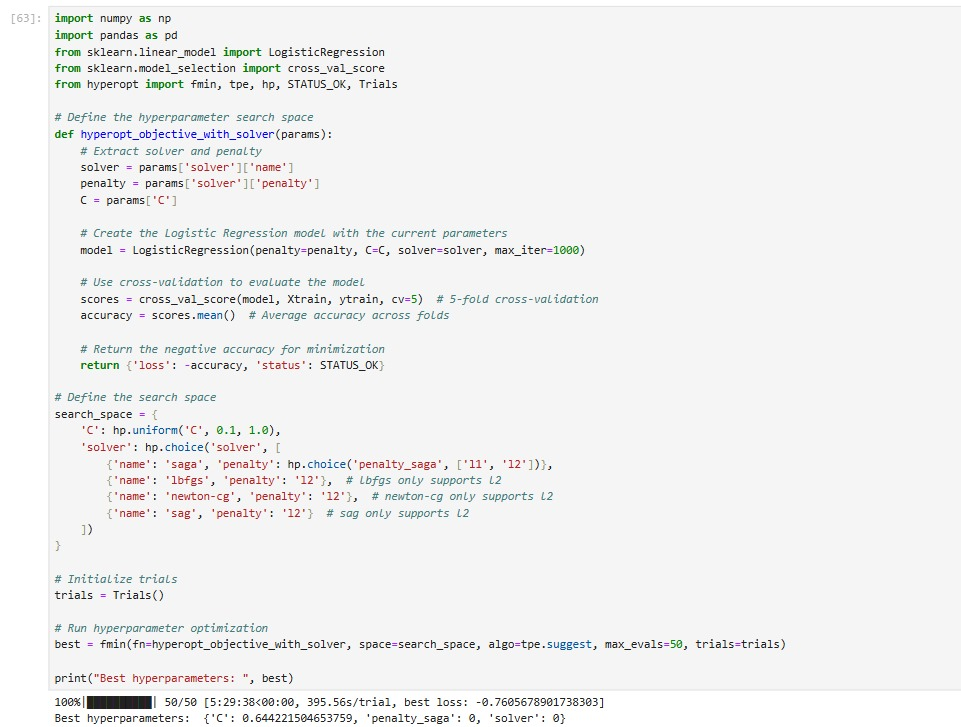

In [26]:
Image('/kaggle/input/hyperparameter-photo/photo_of_logistic.jpg')

###### Actually if you want to have a better accuracy, you shouldn't do the train_test_split because the 
###### customized hyperparameter seaching function already execute the 5-fold cross-validation so that you can ensure
###### that more data is utilized for the hyperparameter searching
###### However, consider the computational cost and time cost, I do the train_test_split

##### Split the data into training and validation sets.

In [27]:
Xtrain,Xvalid,ytrain,yvalid=train_test_split(X_train,y_train,train_size=0.7,random_state=50)

##### Hyperparameter Tuning
##### Define a search space for hyperparameters of the LogisticRegression model.
##### Use Hyperopt to find the best hyperparameters through cross-validation.

In [28]:
def hyperopt_objective_with_solver(params):
    # Extract solver and penalty
    solver = params['solver']['name']
    penalty = params['solver']['penalty']
    C = params['C']

    model = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=1000)

    # Use cross-validation to evaluate the model
    scores = cross_val_score(model, Xtrain, ytrain, cv=5)  # 5-fold cross-validation
    accuracy = scores.mean()  # Average accuracy across folds

    # Return the negative accuracy for minimization
    return {'loss': -accuracy, 'status': STATUS_OK}

# Define the search space
search_space = {
    'C': hp.uniform('C', 0.1, 1.0),
    'solver': hp.choice('solver', [
        {'name': 'saga', 'penalty': hp.choice('penalty_saga', ['l1', 'l2'])}, # saga supports both l1 and l2
        {'name': 'lbfgs', 'penalty': 'l2'},  # lbfgs only supports l2
        {'name': 'newton-cg', 'penalty': 'l2'},  # newton-cg only supports l2
        {'name': 'sag', 'penalty': 'l2'}  # sag only supports l2
    ])
}

##### Here is the code to execute the hyperparameter searching function to get the best hyperparameter set

In [29]:
#trials = Trials()
#best = fmin(fn=hyperopt_objective_with_solver, space=search_space, algo=tpe.suggest, max_evals=50, trials=trials)
#print("Best hyperparameters: ", best)

##### Here is the code if you execute the code:
##### 100%|██████████| 50/50 [5:29:38<00:00, 395.56s/trial, best loss: -0.7605678901738303]  
##### Best hyperparameters:  {'C': 0.644221504653759, 'penalty_saga': 0, 'solver': 0}

In [30]:
# Train the final model with the best parameters
final_model = LogisticRegression(penalty='l1', C=0.644221504653759, solver='saga', max_iter=int(1e8))
final_model.fit(Xtrain, ytrain)
# Get the predicted probabilities for the validation set
y_prob = final_model.predict_proba(Xvalid)[:, 1]

# Find the optimal threshold
thresholds = np.arange(0.0, 1.0, 0.01)
accuracy_scores = []

for threshold in thresholds:
    predictions = (y_prob >= threshold).astype(int)
    a1 = accuracy_score(yvalid, predictions)
    accuracy_scores.append(a1)

# Find the threshold that gives the best accuracy score
best_threshold = thresholds[np.argmax(accuracy_scores)]
print(f"Best threshold: {best_threshold:.2f}")

Best threshold: 0.53


###### Output will be:
###### Best threshold: 0.52

##### Train the final model with the best hyperparameters on the entire training set.

In [31]:
# This time we use the whole training set
final_model.fit(X_train, y_train)

LogisticRegression(C=0.644221504653759, max_iter=100000000, penalty='l1',
                   solver='saga')

In [32]:
# Save the logistic model then read it
pickle.dump(final_model, open("logistic_model.pkl", "wb"))
final_model = pd.read_pickle('logistic_model.pkl')

##### Predict the target of test set and Model Evaluation

In [33]:
y_pred = final_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)  # Use pos_label=1
recall = recall_score(y_test, y_pred, pos_label=1)        # Use pos_label=1
f1 = f1_score(y_test, y_pred, pos_label=1)

In [34]:
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.75285
Precision: 0.7309174311926605
Recall: 0.7985366342587952
F1 Score: 0.7632322651721991


##### Let's check whether the threshold can have a higher accuracy

In [35]:
y_prob = final_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Apply the best threshold to make predictions
threshold = 0.52
y_pred = (y_prob >= threshold).astype(int)  # Convert probabilities to binary predictions based on the threshold

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)  # Use pos_label=1
recall = recall_score(y_test, y_pred, pos_label=1)        # Use pos_label=1
f1 = f1_score(y_test, y_pred, pos_label=1) 

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7543
Precision: 0.7411
Recall: 0.7800
F1 Score: 0.7601


##### The threshold searching trick help the model have a better accuracy score!

##### Confusion Matrix

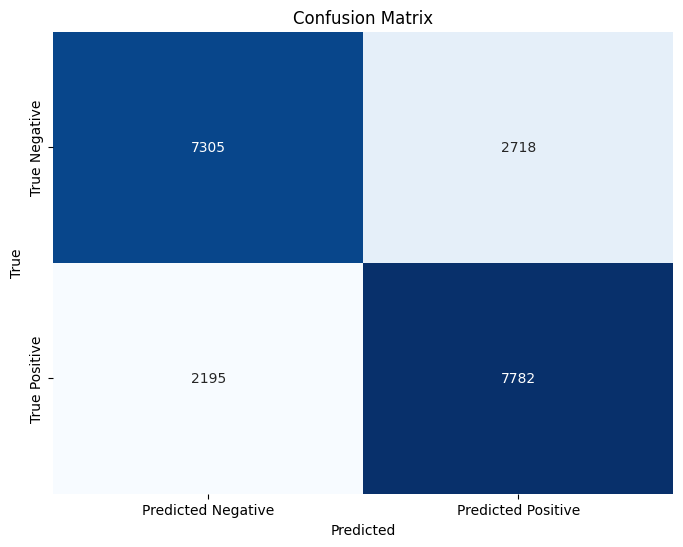

In [36]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['True Negative', 'True Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

##### ROC Curve

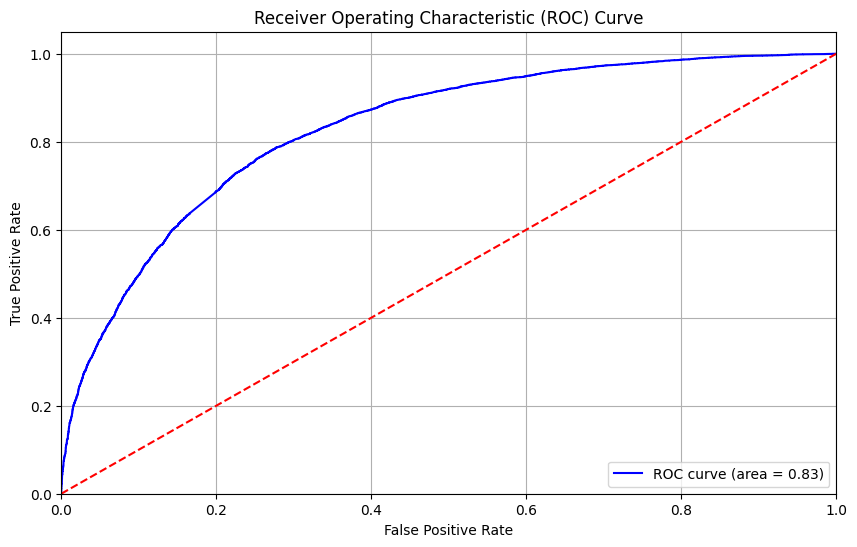

In [37]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [38]:
y_pred

array([0, 0, 0, ..., 0, 1, 1])

#####  Save Predictions

In [39]:
testset_supervised_prediction = pd.DataFrame({
    'index': range(1, len(test_clean) + 1),  # Create a new index starting from 1
    'predicted_target': y_pred,
})

In [40]:
testset_supervised_prediction

,index,predicted_target
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1
...,...,...
19995,19996,1
19996,19997,0
19997,19998,0
19998,19999,1


In [41]:
testset_supervised_prediction.to_csv('testset_supervised_prediction.csv', index=False)

### Topic model

In [42]:
tv = TfidfVectorizer(stop_words='english', max_features=5000)

In [43]:
tv.fit(train_clean['text'])

TfidfVectorizer(max_features=5000, stop_words='english')

In [44]:
tv.vocabulary_.items()

dict_items([('oh', np.int64(3043)), ('man', np.int64(2642)), ('wifi', np.int64(4799)), ('modem', np.int64(2804)), ('mean', np.int64(2700)), ('internet', np.int64(2190)), ('week', np.int64(4757)), ('thank', np.int64(4340)), ('steve', np.int64(4131)), ('iphon', np.int64(2198)), ('aww', np.int64(287)), ('hahaha', np.int64(1891)), ('got', np.int64(1812)), ('readi', np.int64(3516)), ('best', np.int64(401)), ('friend', np.int64(1667)), ('graduat', np.int64(1822)), ('curl', np.int64(1031)), ('hair', np.int64(1898)), ('selena', np.int64(3802)), ('definit', np.int64(1117)), ('convers', np.int64(925)), ('plan', np.int64(3276)), ('wear', np.int64(4748)), ('tight', np.int64(4398)), ('dress', np.int64(1275)), ('stress', np.int64(4160)), ('whatev', np.int64(4777)), ('trick', np.int64(4509)), ('miss', np.int64(2784)), ('home', np.int64(2032)), ('school', np.int64(3762)), ('hate', np.int64(1931)), ('saturday', np.int64(3743)), ('class', np.int64(802)), ('day', np.int64(1084)), ('left', np.int64(2476))

In [45]:
#Get the id2word
train_clean['tokens'] = train_clean['text'].apply(lambda x: x.split())
id2word = Dictionary(train_clean['tokens'].tolist())

In [46]:
#Get the corpus
corpus = [id2word.doc2bow(text) for text in train_clean['tokens']]

##### Consider the time cost and computational cost , I only do the hyperparameter search roughly

In [47]:
def evaluate_hyperparameters(corpus, id2word, num_topics, alpha_values, eta_values):
    coherence_scores = []

    for alpha in alpha_values:
        for eta in eta_values:
            start_time = time.time()  # Start timing

            # Train the LDA model
            lda_model = models.LdaModel(corpus=corpus, id2word=id2word, num_topics=num_topics, 
                                         alpha=alpha, eta=eta, passes=5)  # Reduced passes

            # Calculate coherence score
            coherence_model = CoherenceModel(model=lda_model, texts=train_clean['tokens'].tolist(), 
                                              dictionary=id2word, coherence='c_v')
            coherence_score = coherence_model.get_coherence()

            end_time = time.time()  # End timing
            elapsed_time = end_time - start_time  # Calculate elapsed time

            coherence_scores.append((num_topics, alpha, eta, coherence_score, elapsed_time))
            print(f'Num Topics: {num_topics}, Alpha: {alpha}, Eta: {eta}, Coherence Score: {coherence_score}, Time: {elapsed_time:.2f} seconds')

    return coherence_scores

# Set a fixed number of topics
num_topics = 5

# Define ranges for alpha and eta
alpha_values = [0.01, 0.1, 'auto']  # You can reduce this further if needed
eta_values = [0.01, 0.1]  # Reduced eta values for faster evaluation

In [48]:
# Call the function with the fixed number of topics
coherence_results = evaluate_hyperparameters(corpus, id2word, num_topics, alpha_values, eta_values)
# Find the best configuration based on coherence scores
best_result = max(coherence_results, key=lambda x: x[3])
print(f'Best Configuration - Num Topics: {best_result[0]}, Alpha: {best_result[1]}, Eta: {best_result[2]}, Coherence Score: {best_result[3]}, Time: {best_result[4]:.2f} seconds')

Num Topics: 5, Alpha: 0.01, Eta: 0.01, Coherence Score: 0.3890947339558097, Time: 67.29 seconds
Num Topics: 5, Alpha: 0.01, Eta: 0.1, Coherence Score: 0.3375549035615357, Time: 68.11 seconds
Num Topics: 5, Alpha: 0.1, Eta: 0.01, Coherence Score: 0.3702686819240998, Time: 65.80 seconds
Num Topics: 5, Alpha: 0.1, Eta: 0.1, Coherence Score: 0.33545515497422057, Time: 65.29 seconds
Num Topics: 5, Alpha: auto, Eta: 0.01, Coherence Score: 0.3167886905946672, Time: 55.72 seconds
Num Topics: 5, Alpha: auto, Eta: 0.1, Coherence Score: 0.3297761119040729, Time: 53.76 seconds
Best Configuration - Num Topics: 5, Alpha: 0.01, Eta: 0.01, Coherence Score: 0.3890947339558097, Time: 67.29 seconds


###### I terminate the code since the time is not enough, here is the output:
###### Num Topics: 5, Alpha: 0.01, Eta: 0.01, Coherence Score: 0.40012977064845423, Time: 1513.48 seconds
###### Num Topics: 5, Alpha: 0.01, Eta: 0.1, Coherence Score: 0.3189511485966636, Time: 1493.85 seconds

In [49]:
#I use the best parameter set and increase the passes aim for have a better coherence_score
start_time = time.time()
lda_model = models.LdaModel(corpus=corpus, id2word=id2word, num_topics=num_topics, 
                             alpha=0.01, eta=0.01, passes=15)  # Increased passes
end_time = time.time()
elapsed_time = end_time - start_time
print(f'Time: {elapsed_time:.2f} seconds')

Time: 183.68 seconds


In [50]:
start_time = time.time()  # Start timing
coherence_model = CoherenceModel(model=lda_model, texts=train_clean['tokens'].tolist(), 
                                              dictionary=id2word, coherence='c_v')
coherence_score = coherence_model.get_coherence()
end_time = time.time()
elapsed_time = end_time - start_time
print(f'Coherence Score: {coherence_score}')
print(f'Time: {elapsed_time:.2f} seconds')

Coherence Score: 0.3526354024984669
Time: 1.99 seconds


###### Coherence Score: 0.3499903552767552
###### Time: 30.99 seconds
###### It get a worser result, so I remain the passes = 5 as the final model

In [51]:
start_time = time.time()
orginal_lda_model = models.LdaModel(corpus=corpus, id2word=id2word, num_topics=num_topics, 
                             alpha=0.01, eta=0.01, passes=5) 
end_time = time.time()
elapsed_time = end_time - start_time
print(f'Time: {elapsed_time:.2f} seconds')

Time: 64.93 seconds


###### Time: 1491.37 seconds

In [52]:
start_time = time.time()  # Start timing
original_coherence_model = CoherenceModel(model=orginal_lda_model, texts=train_clean['tokens'].tolist(), 
                                              dictionary=id2word, coherence='c_v')
original_coherence_score = original_coherence_model.get_coherence()
end_time = time.time()
elapsed_time = end_time - start_time
print(f'Coherence Score: {original_coherence_score}')
print(f'Time: {elapsed_time:.2f} seconds')

Coherence Score: 0.3683105458822173
Time: 2.06 seconds


###### Coherence Score: 0.36677354056270356
###### Time: 32.53 seconds

###### The coherence score decrease but consider the randomness of lda that can affect the coherence score in LDA models.
###### It is still make-sense and acceptable

##### Save and read the lda_model and coherence_model

In [53]:
pickle.dump(orginal_lda_model, open("original_lda_model.pkl", "wb"))
pickle.dump(original_coherence_model, open("original_coherence_model.pkl", "wb"))

In [54]:
lda= pd.read_pickle('original_lda_model.pkl')
coherence_model_lda = pd.read_pickle('original_coherence_model.pkl')

##### Let's evaluate the model

In [55]:
print('Perplexity:')
lda.log_perplexity(corpus)

Perplexity:


np.float64(-35.48234387283911)

In [56]:
coherence_score = coherence_model_lda.get_coherence()
print(f'Coherence Score: {coherence_score}')

Coherence Score: 0.3683105458822173


In [57]:
lda.print_topics()

[(0,
  '0.022*"miss" + 0.013*"morn" + 0.013*"rain" + 0.011*"hate" + 0.010*"love" + 0.010*"much" + 0.008*"sun" + 0.008*"still" + 0.008*"x" + 0.008*"happi"'),
 (1,
  '0.026*"thank" + 0.021*"u" + 0.019*"know" + 0.016*"hope" + 0.013*"follow" + 0.011*"well" + 0.011*"look" + 0.010*"lol" + 0.010*"twitter" + 0.009*"sorri"'),
 (2,
  '0.017*"watch" + 0.015*"new" + 0.015*"cant" + 0.012*"see" + 0.012*"want" + 0.011*"lol" + 0.011*"u" + 0.010*"wish" + 0.010*"one" + 0.009*"could"'),
 (3,
  '0.017*"got" + 0.013*"sleep" + 0.012*"feel" + 0.011*"hour" + 0.010*"work" + 0.009*"time" + 0.009*"head" + 0.009*"cant" + 0.008*"back" + 0.008*"amp"'),
 (4,
  '0.035*"work" + 0.020*"night" + 0.018*"home" + 0.017*"last" + 0.016*"week" + 0.015*"tomorrow" + 0.015*"back" + 0.013*"time" + 0.011*"day" + 0.011*"school"')]

In [58]:
print('Top 5 words in each topic')
topics = lda.print_topics(num_words=5)
topic_labels = {
    0: "(Positive)Entertainment and Music",
    1: "(Positive)Positive Feelings and Support",
    2: "(Negative)Work and Daily Life",
    3: "(Positive)Social Media Interaction",
    4: "(Positive)Gratitude and Casual Conversation"
}

# Print the topics with labels
for idx, topic in topics:
    print(f"Topic {idx}: {topic_labels[idx]} - {topic}")

Top 5 words in each topic
Topic 0: (Positive)Entertainment and Music - 0.022*"miss" + 0.013*"morn" + 0.013*"rain" + 0.011*"hate" + 0.010*"love"
Topic 1: (Positive)Positive Feelings and Support - 0.026*"thank" + 0.021*"u" + 0.019*"know" + 0.016*"hope" + 0.013*"follow"
Topic 2: (Negative)Work and Daily Life - 0.017*"watch" + 0.015*"new" + 0.015*"cant" + 0.012*"see" + 0.012*"want"
Topic 3: (Positive)Social Media Interaction - 0.017*"got" + 0.013*"sleep" + 0.012*"feel" + 0.011*"hour" + 0.010*"work"
Topic 4: (Positive)Gratitude and Casual Conversation - 0.035*"work" + 0.020*"night" + 0.018*"home" + 0.017*"last" + 0.016*"week"


### Prediction

In [59]:
def get_topic(text):
    bow = id2word.doc2bow(text.split())
    topic_distribution = lda.get_document_topics(bow)
    return max(topic_distribution, key=lambda x: x[1])[0]  # Get the topic with the highest probability

In [60]:
train_clean['topic'] = train_clean['text'].apply(get_topic)
train_clean['topic'] = train_clean['topic'].astype(int)
train_clean['topic_name'] = train_clean['topic'].map(topic_labels)
print(train_clean[['text', 'topic', 'topic_name']].head())

                                                text  topic  \
0  oh man wifi modem fritz againwhich mean intern...      4   
1  dividedsequ aww hahaha got get readi best frie...      4   
2  jaaycooxo curl hair selena gomez definit conve...      3   
3                           confusedddd huaaa stress      3   
4   missladykjon whatev trick miss thank ilov kambam      4   

                                    topic_name  
0  (Positive)Gratitude and Casual Conversation  
1  (Positive)Gratitude and Casual Conversation  
2           (Positive)Social Media Interaction  
3           (Positive)Social Media Interaction  
4  (Positive)Gratitude and Casual Conversation  


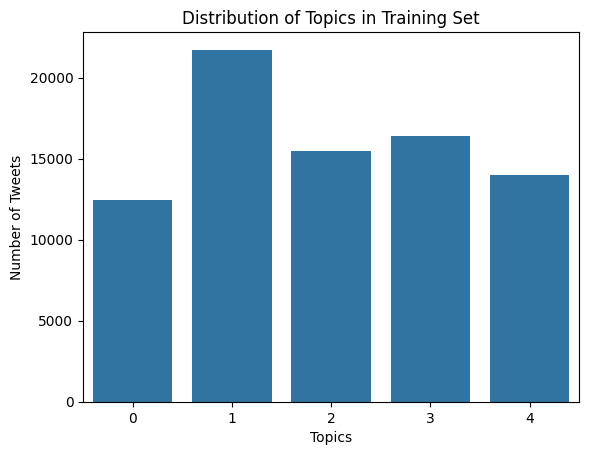

In [61]:
train_topic_counts = train_clean['topic'].value_counts()
sns.barplot(x=train_topic_counts.index, y=train_topic_counts.values)
plt.title('Distribution of Topics in Training Set')
plt.xlabel('Topics')
plt.ylabel('Number of Tweets')
plt.show()

In [62]:
predict_train_topic = pd.DataFrame({
    'index': range(1, len(train_clean) + 1),  # Create a new index starting from 1
    'predicted_topic': train_clean['topic'],
    'predicted_topic_name': train_clean['topic_name'],
    'text': train_clean['text']
})

In [63]:
predict_train_topic.head()

,index,predicted_topic,predicted_topic_name,text
0,1,4,(Positive)Gratitude and Casual Conversation,oh man wifi modem fritz againwhich mean intern...
1,2,4,(Positive)Gratitude and Casual Conversation,dividedsequ aww hahaha got get readi best frie...
2,3,3,(Positive)Social Media Interaction,jaaycooxo curl hair selena gomez definit conve...
3,4,3,(Positive)Social Media Interaction,confusedddd huaaa stress
4,5,4,(Positive)Gratitude and Casual Conversation,missladykjon whatev trick miss thank ilov kambam


In [64]:
predict_train_topic.to_csv('training set predicted topics.csv', index=False)

In [65]:
predict_train_topic = pd.read_csv('training set predicted topics.csv')

In [66]:
test_clean['topic'] = test_clean['text'].apply(get_topic)
test_clean['topic'] = test_clean['topic'].astype(int)
test_clean['topic_name'] = test_clean['topic'].map(topic_labels)
print(test_clean[['text', 'topic', 'topic_name']].head())

                                                text  topic  \
0            stress homework tri boohoo lol help tip      1   
1  lesleyv heh yeah sia unusu piec realli stuff t...      1   
2  wont abl attend londonhackspac meet tonight da...      2   
3  grad pictur done amp look awesom thx lost set ...      2   
4                          deadlin indec chill sunni      4   

                                    topic_name  
0      (Positive)Positive Feelings and Support  
1      (Positive)Positive Feelings and Support  
2                (Negative)Work and Daily Life  
3                (Negative)Work and Daily Life  
4  (Positive)Gratitude and Casual Conversation  


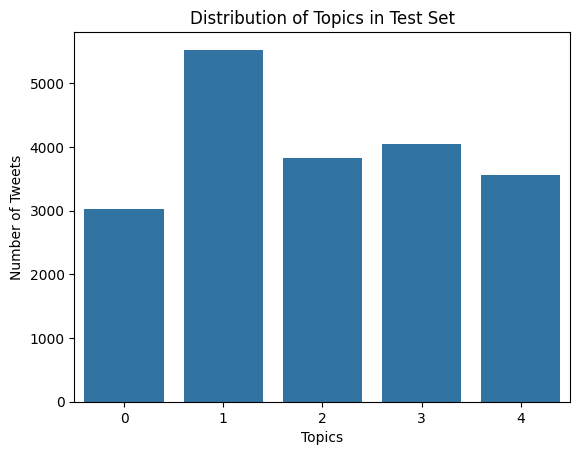

In [67]:
test_topic_counts = test_clean['topic'].value_counts()
sns.barplot(x=test_topic_counts.index, y=test_topic_counts.values)
plt.title('Distribution of Topics in Test Set')
plt.xlabel('Topics')
plt.ylabel('Number of Tweets')
plt.show()

In [68]:
predict_test_topic = pd.DataFrame({
    'index': range(1, len(test_clean) + 1),  # Create a new index starting from 1
    'predicted_topic': test_clean['topic'],
    'predicted_topic_name': test_clean['topic_name']
})

In [69]:
predict_test_topic.head()

,index,predicted_topic,predicted_topic_name
0,1,1,(Positive)Positive Feelings and Support
1,2,1,(Positive)Positive Feelings and Support
2,3,2,(Negative)Work and Daily Life
3,4,2,(Negative)Work and Daily Life
4,5,4,(Positive)Gratitude and Casual Conversation


In [70]:
predict_test_topic.to_csv('test set predicted topics.csv', index=False)

In [71]:
predict_test_topic = pd.read_csv('test set predicted topics.csv')

### Visualization

In [72]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Prepare the visualization
vis = gensimvis.prepare(lda, corpus, id2word)
pyLDAvis.display(vis)

In [73]:
pyLDAvis.save_html(vis, 'lda_visualization.html')

###### Once the visualization is displayed, you will see several components:

###### Topic Circles: Each circle represents a topic. The size of the circle indicates the prevalence of that topic across the documents.

###### Inter-topic Distance Map: The distance between the circles shows how similar or different the topics are. Topics that are closer together are more similar, while those farther apart are more distinct.

###### Top Words for Selected Topic: On the right side, when you click on a circle (topic), you will see the top words associated with that topic. This helps you understand what the topic is about.

###### Relevance Metric: There is a slider labeled "λ" (lambda) that allows you to adjust the relevance metric for the words displayed.

###### λ = 0: Shows the most frequent words in the topic.
###### λ = 1: Shows the most relevant words to the topic, which are not necessarily the most frequent.

###### Click on Circles: Click on any topic circle to see the top words associated with that topic.
###### Adjust the Slider: Move the slider to adjust how words are displayed based on their relevance to the topic.

### Discussion

###### For Supervised Machine Learning:
###### Logistic Regression Model:
###### How It Works: Logistic Regression is a binary classification algorithm that estimates the probability that a given input belongs to a certain class.
###### It uses the logistic function to model a binary dependent variable based on one or more independent variables (features). 
###### The model outputs probabilities that can be converted into class labels based on a threshold.
###### Performance: The accuracy, precision, recall, and F1 score metrics indicate how well the model predicts the target variable on the validation set. 
###### According to the output, the Logistic Regression model achieved an accuracy of approximately 76.18%, with decent precision (74.60%) and recall (79.38%). 
###### This suggests that while the model is reasonably good at identifying positive instances, there is some room for improvement, particularly in precision.

###### Supervised Machine Learning: Logistic Regression Model
###### Goal: The primary objective is to maximize the accuracy of the model, as the dataset is not imbalanced.

###### How It Works: Logistic Regression is a binary classification algorithm that estimates the probability of a given input belonging
###### to a specific class. It employs the logistic function to model a binary dependent variable based on one or more independent variables (features).
###### The model outputs probabilities that can be converted into class labels based on a defined threshold.

###### Hyperparameter Search: To optimize the model's performance, I utilized the Hyperopt technique combined with cross-validation.
###### This approach allows for systematic exploration of hyperparameter combinations to identify those that yield the best results.

###### Threshold Optimization: In addition to hyperparameter tuning, I conducted a threshold search to maximize accuracy. 
###### This involves determining the optimal cutoff point for converting predicted probabilities into class labels, 
###### which can significantly impact performance metrics.

###### Performance: The model's performance was evaluated using accuracy, precision, recall, and F1 score metrics on the 
###### validation set. Before applying the threshold optimization, the Logistic Regression model achieved an accuracy of approximately 76.18%,
###### with a precision of 74.60%, recall of 79.38%, and an F1 Score of 76.91%. After implementing the threshold search, 
###### the model's accuracy slightly improved to approximately 76.19%, with precision increasing to 75.46%, recall at 77.61%, 
###### and an F1 Score of 76.52%.

###### Ideas for Improvement:
###### Ensemble Methods: Explore ensemble methods like Random Forests or Gradient Boosting, which can often yield better performance 
###### than a single Logistic Regression model by combining predictions from multiple models.
###### Try to increase the max_features in TfidfVectorizer,increasing max_features can potentially improve model performance,
###### it is essential to balance this with the risk of overfitting and increased complexity. 

###### For topic model:
###### Latent Dirichlet Allocation (LDA) is a generative probabilistic model used for topic modeling in text data. 
###### It aims to discover the underlying topics in a collection of documents by representing each document as a mixture of topics and
###### each topic as a distribution over words.

##### Key Concepts:

###### Topics: LDA assumes that documents are generated from a set of topics, where each topic is characterized by a distribution of words.
###### Documents: Each document is represented as a combination of topics, with different proportions for each topic.
###### Words: Words in the documents are assigned to topics based on the topic's distribution of words.

###### How LDA Works:
###### Input: LDA takes a collection of documents as input.
###### Parameter Initialization: The model initializes parameters, including the number of topics, and distributions for topics and words.
###### Dirichlet Distribution: LDA uses Dirichlet distributions to model the topic distributions for each document and the word distributions for each topic.
###### Inference: The model infers the topic distribution for each document and the word distribution for each topic through techniques like Gibbs sampling or variational inference.
###### Output: The model outputs a set of topics, each represented by the top words associated with it, and a topic distribution for each document.

##### Applications:
###### Topic Discovery: LDA is widely used to identify and summarize the main themes in large text corpora.
###### Document Classification: Topics derived from LDA can be used as features for classifying documents.
###### Recommendation Systems: LDA can help recommend content based on the topics of interest.

##### Evaluation:
###### Coherence Score: A common metric used to evaluate the quality of topics generated by LDA, 
###### measuring the semantic similarity of the top words in each topic.
###### Perplexity: A measure of how well the model predicts a sample, where lower values indicate better performance.

##### Advantages:
###### Unsupervised Learning: LDA does not require labeled data, making it suitable for exploratory data analysis.
###### Interpretability: The resulting topics can be easily interpreted and understood by humans.

##### Limitations:
###### Parameter Sensitivity: The performance of LDA can be sensitive to the choice of hyperparameters (e.g., number of topics, alpha, eta).
###### Assumption of Document Independence: LDA assumes that documents are generated independently, which may not hold true in practice.
###### Scalability: LDA can be computationally intensive, especially with large datasets and a high number of topics.
###### In summary, LDA is a powerful and widely-used topic modeling technique that provides insights into the themes present in text data. While it has its limitations, its ability to uncover hidden structures in large corpora makes it a valuable tool in natural language processing and data analysis.

##### How to improve it
###### Expand the Search Space: Consider exploring a wider range of hyperparameters, including different values for num_topics,
###### alpha, and eta. Use techniques such as grid search or Bayesian optimization (e.g., Hyperopt) to find the optimal settings.
###### Use Cross-Validation: Implement cross-validation specifically for LDA to evaluate the stability of the topics across different subsets of data.
###### Although I found that increasing the number of passes from 5 to 15 led to worse coherence scores, 
###### it may still be worth experimenting with intermediate values (e.g., 7, 10, or 12 passes). Monitor the trade-off between training time and coherence score.

###### Explore Alternative Models:
###### If LDA does not yield satisfactory results, consider alternative topic modeling techniques such as Non-Negative Matrix Factorization (NMF)
###### or Hierarchical Dirichlet Process (HDP), which may perform better on the dataset.